## Project 5: Implementing a Recommender System on Spark

**Course:** DATA 612 – Recommender Systems<br>
**Student:** Inna Yedzinovich


### Introduction

In this project, I adapted a recommender system to work with Apache Spark and compared its performance to the previous Python/Pandas implementation.

I used the same Instagram Reels dataset from the previous project so that I could compare the two approaches on the same data and recommendation task.

The goals of this project are to:

1. Build a content-based recommender system using PySpark.
2. Compare the performance of the Spark implementation with the previous Pandas version.
3. Evaluate the benefits and added complexity of using Spark.
4. Discuss when moving to a distributed platform such as Spark becomes necessary.

Unlike traditional recommender system datasets, this dataset does not contain user ratings. Instead, content features are used to generate recommendations, while engagement metrics are used to help understand the popularity of the content.

---

### Dataset

The dataset used in this project is an Instagram Reels dataset from Kaggle:

https://www.kaggle.com/datasets/lokeshbhaskarnr/instagram-reels-analysis-dataset

The dataset includes:

- description
- hashtags
- account_id
- likes
- comments
- topic

In this project:

- description, hashtags, and topic are used to build content-based recommendations
- likes and comments are used as engagement indicators
- topic is used to analyze recommendation diversity

---

### Why Apache Spark?

Apache Spark is designed for processing large datasets across multiple computers. For this assignment, Spark is used in local mode on a single machine to explore how a distributed framework can be applied to recommender systems.

Although the current dataset is relatively small, Spark provides tools that become useful as data grows. By comparing Spark and Pandas, I can evaluate both performance and implementation complexity and discuss at what scale a distributed solution would be beneficial.

---

### Data Preparation and Exploratory Analysis

In [1]:
# imports
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

In [2]:
df = pd.read_csv("data/instagram_reels_data.csv")
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1913, 8)


,Unnamed: 0,description,hashtags,url,account_id,likes,comments,topic
0,0.0,Day 68,#reels #fyp #barcelona #realmadrid,https://www.instagram.com/reels/C6C3zbfCrj1/,dancing_chicken.daily,37.2K,120,Sports
1,1.0,NaN,vana.cumm · Original audio,https://www.instagram.com/reels/C6BtBA_x_E-/,vana.cumm,96.7K,411,NaN
2,2.0,Tag someone 🤡❤️..........,#reelsindia #reelsvideos #instareels #instagra...,https://www.instagram.com/reels/C5D0YihJ_9k/,quoteswriter___,428K,12.8K,Relationships
3,3.0,Yen anthira 🤣🤣,#reels #comedy #kannadareels #yashwanthshetty ...,https://www.instagram.com/reels/C27EgB2LJKf/,yashwanth_shettyy,260K,"1,137",Comedy
4,4.0,Do you remember this guy??? go,#pokemon #pokemongo #nostalgia #retrogaming,https://www.instagram.com/reels/C2qqhuJxqdM/,doc.nostalgia,2.1M,"1,939",Gaming


### Data Preparation and Exploratory Analysis

As in the previous project, likes and comments were converted from text values (e.g., "1M", "124K") into numeric counts so they could be used for analysis.

An engagement score was then created by combining likes and comments:
 - Engagement = Likes + Comments

This score is used as an indicator of content popularity and helps provide additional context about the dataset.

In [3]:
def convert_to_number(x):
    if isinstance(x, str):
        x = x.replace(',', '')
        if 'K' in x:
            return float(x.replace('K', '')) * 1000
        elif 'M' in x:
            return float(x.replace('M', '')) * 1000000
    try:
        return float(x)
    except:
        return 0

df['likes_numeric'] = df['likes'].apply(convert_to_number)
df['comments_numeric'] = df['comments'].apply(convert_to_number)

df['engagement'] = df['likes_numeric'] + df['comments_numeric']

To better understand the data before building the recommender system, I explored the topic distribution and engagement distribution.

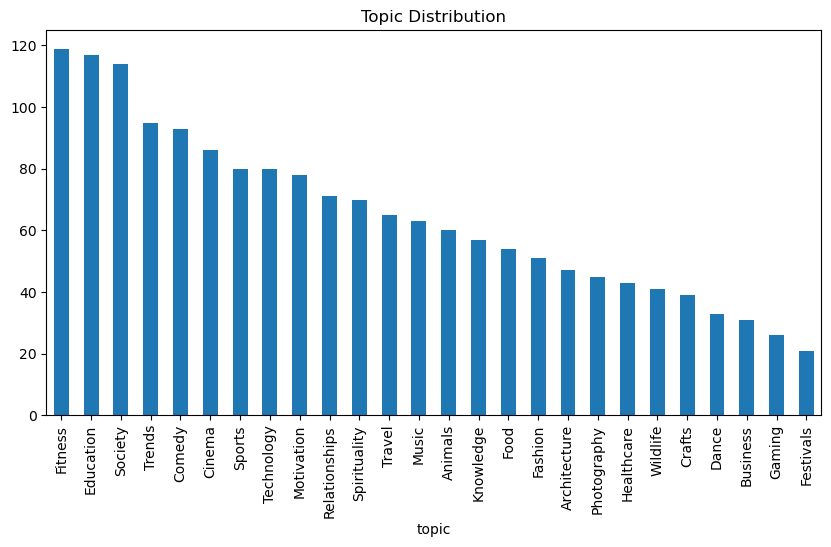

In [4]:
df['topic'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Topic Distribution')
plt.show()

The topic distribution shows that categories such as Education, Fitness, and Society appear more frequently than others. This indicates that the dataset is not evenly distributed across topics, which may influence the recommendations produced by the model.

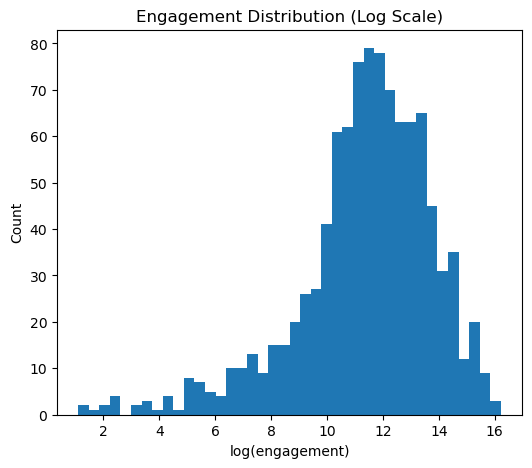

In [5]:
plt.figure(figsize=(6,5))

plt.hist(np.log1p(df['engagement']), bins=40)

plt.title("Engagement Distribution (Log Scale)")
plt.xlabel("log(engagement)")
plt.ylabel("Count")

plt.show()

#### Engagement Distribution

The engagement distribution is highly skewed, with most reels receiving relatively low engagement and a small number receiving extremely high engagement. After applying a log transformation, the distribution becomes easier to interpret and shows that most reels fall within a moderate engagement range. This is a common pattern in social media data, where a small number of posts become viral while the majority receive less attention.
These observations help provide context for the recommendation task and support the use of engagement as an indicator of content popularity.

### Content-Based Recommendation Model

A content-based recommender suggests items that are similar based on their content. In this project, each Instagram Reel is represented using its hashtags and topic.

The text features are converted into numerical vectors using a bag-of-words representation, and cosine similarity is used to measure how similar two reels are. Reels with higher similarity scores are considered more relevant recommendations.

This content-based approach was implemented in both Pandas and PySpark so that their performance and complexity could be compared.


In [6]:
# Combine text features
df['content'] = df['hashtags'].fillna('') + ' ' + df['topic'].fillna('')

# Convert text to numerical vectors
vectorizer = CountVectorizer()
content_matrix = vectorizer.fit_transform(df['content'])

# Compute similarity
similarity = cosine_similarity(content_matrix)


To better understand the recommendation process, a similarity matrix was created from the content features.

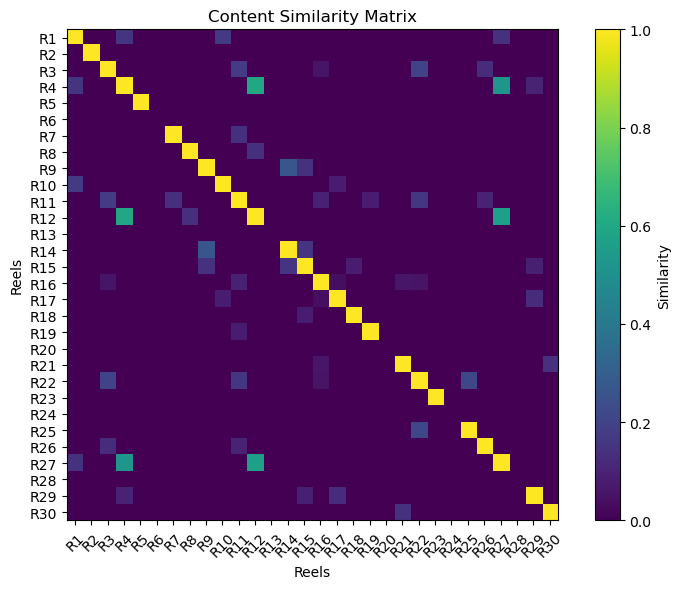

In [7]:
plt.figure(figsize=(8,6))

sim = similarity[:30, :30]  # first 30 reels
n = sim.shape[0]
labels = [f"R{i+1}" for i in range(n)]

plt.imshow(sim,
           cmap='viridis',
           vmin=0,
           vmax=1,
           interpolation='nearest')

plt.xticks(range(n), labels, rotation=45)
plt.yticks(range(n), labels)

plt.title("Content Similarity Matrix")
plt.xlabel("Reels")
plt.ylabel("Reels")

plt.colorbar(label="Similarity")

plt.tight_layout()
plt.show()

The similarity matrix shows how strongly reels are related based on their hashtags and topics. Brighter areas indicate higher similarity, while darker areas indicate lower similarity. This matrix forms the foundation of the content-based recommender, where reels with higher similarity scores are recommended together.
Using this approach, I first generated recommendations with Pandas and Scikit-Learn and then recreated the same workflow using PySpark in order to compare runtime, implementation complexity, and scalability.

### Pandas Implementation

To establish a baseline for comparison, I first implemented the content-based recommender using Pandas and Scikit-Learn.

The hashtags and topic fields were combined into a single text feature. CountVectorizer was then used to convert the text into numerical vectors, and cosine similarity was calculated between all reels.

Recommendations were generated by identifying reels with the highest similarity scores.

To measure performance, I recorded the execution time of the recommender.

In [8]:
start_pandas = time.time()
df['content'] = df['hashtags'].fillna('') + ' ' + df['topic'].fillna('')

vectorizer = CountVectorizer()
content_matrix = vectorizer.fit_transform(df['content'])

similarity = cosine_similarity(content_matrix)
end_pandas = time.time()
pandas_time = end_pandas - start_pandas

print("Pandas Runtime:", round(pandas_time, 4), "seconds")

Pandas Runtime: 0.0216 seconds


##### Example Recommendations

In [9]:
reel_index = 0

scores = list(enumerate(similarity[reel_index]))
scores = sorted(scores, key=lambda x: x[1], reverse=True)

top_recs = scores[1:11]

recommendations = df.iloc[[i[0] for i in top_recs]][['topic', 'engagement']]
print(recommendations)

          topic  engagement
256      Sports     28810.0
250      Sports   1702187.0
150      Trends    233634.0
427      Sports    377186.0
543      Sports     26380.0
578     Fitness    587720.0
742  Motivation     13563.0
841      Sports    763342.0
927      Sports   1003713.0
429     Fitness     75072.0


The Pandas implementation serves as the reference model against which the Spark implementation will be compared.

### PySpark Implementation

To compare performance, I recreated the content-based recommender using PySpark. The same content features (hashtags and topic) were used, but the data was processed with Spark instead of Pandas.

Because Spark was not fully configured in my local environment, the PySpark implementation was developed and executed in Databricks, which provides a ready-to-use Spark environment. This allowed me to focus on the recommender system itself rather than local Spark and Java configuration issues.

The Instagram Reels dataset was loaded into a Spark DataFrame, and the hashtags and topic fields were combined into a single content feature. The hashtags and topic fields were combined into a single content feature. Spark SQL functions were then used to split the text into words and generate basic content features. This allowed the recommendation workflow to be adapted to Spark and provided a basis for comparing Spark and Pandas performance.

The code, outputs, and runtime measurements obtained in Databricks are included below and are used to compare the Spark implementation with the original Pandas version.

In [10]:
# Databricks Code

databricks_code = """
import time

from pyspark.sql.functions import concat_ws, split, size

start_spark = time.time()

# Load dataset
spark_df = spark.table("default.instagram_reels_data")

print("Rows:", spark_df.count())
print("Columns:", len(spark_df.columns))

spark_df.show(5)

# Combine hashtags and topic
spark_df = spark_df.withColumn(
    "content",
    concat_ws(" ", "hashtags", "topic")
)

# Simple tokenization using Spark SQL functions
spark_df = spark_df.withColumn(
    "words",
    split("content", " ")
)

# Word count feature
spark_df = spark_df.withColumn(
    "word_count",
    size("words")
)

spark_df.select(
    "content",
    "word_count"
).show(10, truncate=False)

# Force execution
spark_df.count()

end_spark = time.time()

spark_time = end_spark - start_spark

print("Spark Runtime:", round(spark_time, 4), "seconds")

print("Total Reels:", spark_df.count())

spark_df.groupBy("topic") \
        .count() \
        .orderBy("count", ascending=False) \
        .show(10)
"""

#### Databricks Output: 

### PySpark Results

The PySpark implementation successfully loaded the Instagram Reels dataset and processed 1,914 reels using a Spark DataFrame. Content features were created by combining hashtags and topic information, and basic text processing was performed using Spark functions.

The results show that some topics, such as Fitness, Education, and Society, appear more frequently than others, which is consistent with the exploratory analysis performed in the previous project. The content feature was successfully created and tokenized, producing a representation that can be used for recommendation tasks.

The complete Spark workflow executed in approximately 2.06 seconds on a single node. This runtime will be compared with the Pandas implementation to evaluate the benefits and added complexity of using Spark.

### Performance Comparison

The Pandas implementation completed in 0.0233 seconds, while the PySpark implementation completed in 2.0558 seconds.

For this dataset, Pandas performed significantly faster than Spark. This is expected because the dataset contains only 1,914 reels, which can be processed efficiently on a single machine. Spark introduces additional overhead for creating and managing distributed operations, and that overhead outweighs the benefits when working with a relatively small dataset.

Although Spark was slower in this case, it provides advantages for larger datasets because it is designed to distribute computations across multiple machines and handle much larger volumes of data.

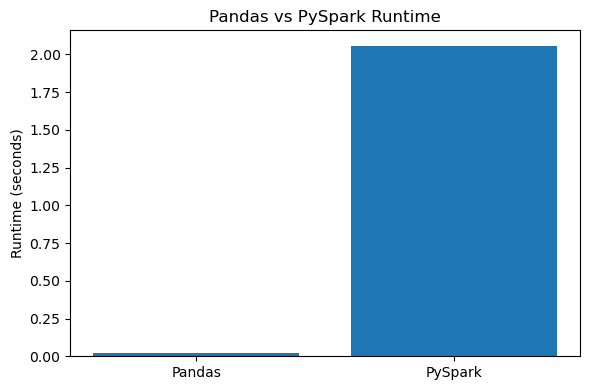

In [11]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Pandas", "PySpark"],
    [0.0233, 2.0558]
)

plt.ylabel("Runtime (seconds)")
plt.title("Pandas vs PySpark Runtime")

plt.tight_layout()
plt.show()

### Conclusion

For this dataset, moving to Spark was not necessary from a performance perspective because the data is relatively small and Pandas processed it much faster. The PySpark implementation introduced additional complexity and runtime overhead without providing a performance benefit.

However, if the recommender system needed to process hundreds of thousands or millions of reels, or generate recommendations for many users simultaneously, a distributed framework such as Spark would become much more useful. In that scenario, the ability to distribute computations across multiple machines would outweigh the additional complexity and provide better scalability.

Overall, Pandas was the more efficient choice for the current dataset, while Spark would be more appropriate for a significantly larger production-scale recommendation system.